In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import polars as pl

event_frames = []
count = 0

for file in Path('data/events').glob('*.json'):
    if count > 100:
        break
    count += 1
    event_frames.append(
        pl.read_json(file, infer_schema_length=None).with_columns(
            pl.lit(int(file.stem), dtype=pl.Int64).alias('match_id')
        )
    )

events_df = pl.concat(event_frames, how='diagonal_relaxed')
base_columns = [
    'id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession',
    'possession_team', 'play_pattern', 'team', 'duration', 'tactics', 'match_id',
    'related_events', 'player', 'position', 'location',
]
events_df = events_df.select(base_columns + [
    column for column in events_df.columns if column not in base_columns
])


In [3]:
non_playing_events_ids = [5, 18, 19, 26, 27, 29, 34, 35, 36, 40]

In [4]:
# rename carry to carry_to
events_df = events_df.rename({'carry': 'carry_to'})


In [5]:
def set_to_id(value):
    return int(value['id']) if isinstance(value, dict) and 'id' in value else value

id_cols = ['type', 'possession_team', 'play_pattern', 'team', 'player', 'position']
events_df = events_df.with_columns(
    pl.col(column).map_elements(set_to_id, return_dtype=pl.Int64).alias(column)
    for column in id_cols
)


In [6]:
cols_to_expand = events_df.columns[18:]
for col in cols_to_expand:
    dtype = events_df.schema[col]
    if isinstance(dtype, pl.Struct):
        events_df = events_df.with_columns(
            pl.col(col).struct.field(field.name).alias(f'{col}_{field.name}')
            for field in dtype.fields
        ).drop(col)


In [7]:
for col in events_df.columns:
    dtype = events_df.schema[col]
    if isinstance(dtype, pl.Struct) and 'id' in {field.name for field in dtype.fields}:
        events_df = events_df.with_columns(pl.col(col).struct.field('id').alias(col))


In [8]:
playing_events_df = events_df.filter(~pl.col('type').is_in(non_playing_events_ids))


In [9]:
playing_events_df = playing_events_df.drop('tactics')


In [10]:
nAn = playing_events_df.get_column('block_deflection').unique().to_list()[0]


In [11]:
print(playing_events_df.schema)


Schema([('id', String), ('index', Int64), ('period', Int64), ('timestamp', String), ('minute', Int64), ('second', Int64), ('type', Int64), ('possession', Int64), ('possession_team', Int64), ('play_pattern', Int64), ('team', Int64), ('duration', Float64), ('match_id', Int64), ('related_events', List(String)), ('player', Int64), ('position', Int64), ('location', List(Float64)), ('counterpress', Boolean), ('under_pressure', Boolean), ('off_camera', Boolean), ('out', Boolean), ('pass_recipient', Int64), ('pass_length', Float64), ('pass_angle', Float64), ('pass_height', Int64), ('pass_end_location', List(Float64)), ('pass_switch', Boolean), ('pass_body_part', Int64), ('pass_type', Int64), ('pass_outcome', Int64), ('pass_aerial_won', Boolean), ('pass_through_ball', Boolean), ('pass_technique', Int64), ('pass_cross', Boolean), ('pass_inswinging', Boolean), ('pass_assisted_shot_id', String), ('pass_shot_assist', Boolean), ('pass_outswinging', Boolean), ('pass_cut_back', Boolean), ('pass_straig

In [12]:
# print list of columns zero-indexed
for i, col in enumerate(playing_events_df.columns):
    print(f"{i}: {col}")

0: id
1: index
2: period
3: timestamp
4: minute
5: second
6: type
7: possession
8: possession_team
9: play_pattern
10: team
11: duration
12: match_id
13: related_events
14: player
15: position
16: location
17: counterpress
18: under_pressure
19: off_camera
20: out
21: pass_recipient
22: pass_length
23: pass_angle
24: pass_height
25: pass_end_location
26: pass_switch
27: pass_body_part
28: pass_type
29: pass_outcome
30: pass_aerial_won
31: pass_through_ball
32: pass_technique
33: pass_cross
34: pass_inswinging
35: pass_assisted_shot_id
36: pass_shot_assist
37: pass_outswinging
38: pass_cut_back
39: pass_straight
40: pass_miscommunication
41: pass_no_touch
42: pass_deflected
43: pass_goal_assist
44: pass_backheel
45: carry_to_end_location
46: ball_receipt_outcome
47: duel_type
48: duel_outcome
49: foul_committed_offensive
50: foul_committed_type
51: foul_committed_card
52: foul_committed_advantage
53: foul_committed_penalty
54: interception_outcome
55: dribble_overrun
56: dribble_outcome

In [13]:
for column in playing_events_df.columns[17:]:
    if playing_events_df.schema[column] == pl.Boolean:
        print(column)
        playing_events_df = playing_events_df.with_columns(pl.col(column).fill_null(False))


counterpress
under_pressure
off_camera
out
pass_switch
pass_aerial_won
pass_through_ball
pass_cross
pass_inswinging
pass_shot_assist
pass_outswinging
pass_cut_back
pass_straight
pass_miscommunication
pass_no_touch
pass_deflected
pass_goal_assist
pass_backheel
foul_committed_offensive
foul_committed_advantage
foul_committed_penalty
dribble_overrun
dribble_nutmeg
dribble_no_touch
clearance_aerial_won
clearance_head
clearance_right_foot
clearance_left_foot
clearance_other
miscontrol_aerial_won
shot_one_on_one
shot_aerial_won
shot_first_time
shot_open_goal
shot_follows_dribble
shot_deflected
shot_saved_off_target
shot_saved_to_post
shot_redirect
goalkeeper_punched_out
goalkeeper_shot_saved_to_post
goalkeeper_shot_saved_off_target
goalkeeper_lost_in_play
goalkeeper_success_in_play
foul_won_advantage
foul_won_defensive
foul_won_penalty
ball_recovery_recovery_failure
ball_recovery_offensive
block_deflection
block_save_block
block_offensive
injury_stoppage_in_chain


In [14]:
from tools_file import *
# load json files 
event_types_dict = json_file_to_dict('info/event_type.json')
positions_dict = json_file_to_dict('info/position.json')
positions_abbrev_dict = json_file_to_dict('info/position.json', value_field='abbrev')
play_patterns_dict = json_file_to_dict('info/play_pattern.json')

In [15]:
end_loc_cols = [s for s in playing_events_df.columns if "end_location" in s]
outcome_cols = [s for s in playing_events_df.columns if "outcome" in s]
type_cols = [s for s in playing_events_df.columns if "_type" in s]
technique_cols = [s for s in playing_events_df.columns if "technique" in s]
body_part_cols = [s for s in playing_events_df.columns if "body_part" in s]
aerial_won_cols = [s for s in playing_events_df.columns if "aerial_won" in s]

playing_events_df = playing_events_df.with_columns(
    pl.coalesce(end_loc_cols).alias('end_location'),
    pl.coalesce(outcome_cols).alias('outcome'),
    pl.coalesce(type_cols).alias('action_type'),
    pl.coalesce(technique_cols).alias('technique'),
    pl.coalesce(body_part_cols).alias('body_part'),
    pl.coalesce(aerial_won_cols).alias('aerial_won'),
).drop(end_loc_cols + outcome_cols + type_cols + technique_cols + body_part_cols + aerial_won_cols)


In [16]:
all_null_columns = [
    column for column in playing_events_df.columns
    if playing_events_df.get_column(column).null_count() == playing_events_df.height
]
playing_events_df = playing_events_df.drop(all_null_columns)


In [17]:
playing_events_df = playing_events_df.with_columns(
    (pl.lit(72) - pl.col('foul_committed_card')).alias('foul_committed_card'),
    (pl.lit(72) - pl.col('bad_behaviour_card')).alias('bad_behaviour_card'),
)


In [18]:
# collapse body part cols
clearance_cols = [s for s in playing_events_df.columns if "clearance_" in s]

playing_events_df = playing_events_df.drop(clearance_cols)


In [19]:
import numpy as np

def split_location(df, col):
    return df.with_columns(
        pl.col(col).list.get(0, null_on_oob=True).alias(f'{col}_x'),
        pl.col(col).list.get(1, null_on_oob=True).alias(f'{col}_y'),
    )

playing_events_df = split_location(playing_events_df, 'location')
playing_events_df = split_location(playing_events_df, 'end_location')
playing_events_df = playing_events_df.drop(['location', 'end_location'])


In [20]:
# get time col and take exact millisecond of event
playing_events_df = playing_events_df.with_columns(
    pl.col('timestamp').str.extract(r'\.(\d+)', 1).fill_null('0').cast(pl.Int64).alias('millisecond')
)


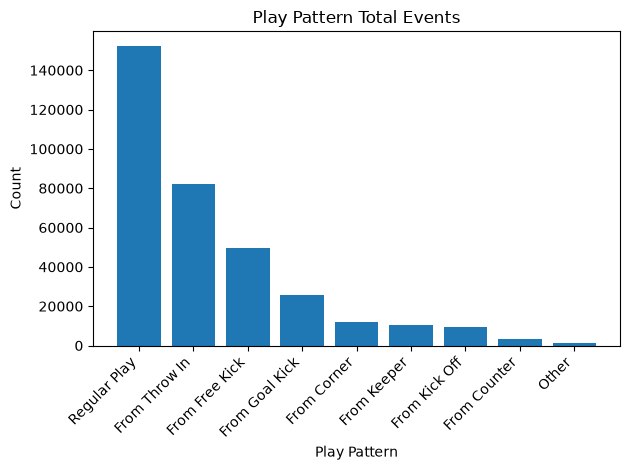

In [21]:
# play patterns type bar chart
import matplotlib.pyplot as plt

counts = playing_events_df.group_by('play_pattern').len().sort('len', descending=True)
counts = counts.with_columns(
    pl.col('play_pattern').replace_strict(play_patterns_dict, default=None).alias('play_pattern')
)

plt.bar(counts['play_pattern'].to_list(), counts['len'].to_list())
plt.title('Play Pattern Total Events')
plt.xlabel('Play Pattern')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Count')

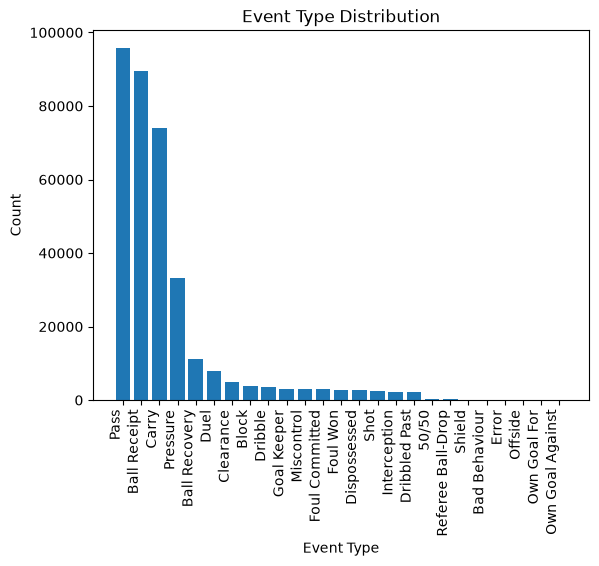

In [22]:
import matplotlib.pyplot as plt
# plot event type distribution
type_counts = playing_events_df.group_by('type').len().sort('len', descending=True)
type_counts = type_counts.with_columns(
    pl.col('type').replace_strict(event_types_dict, default=None).alias('name')
)
plt.bar(type_counts['name'].to_list(), type_counts['len'].to_list())
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.xticks(rotation=90, ha='right')
plt.ylabel("Count")


In [23]:
print(event_types_dict)
print(positions_dict)

{2: 'Ball Recovery', 3: 'Dispossessed', 4: 'Duel', 5: 'Camera On', 6: 'Block', 8: 'Offside', 9: 'Clearance', 10: 'Interception', 14: 'Dribble', 16: 'Shot', 17: 'Pressure', 18: 'Half Start', 19: 'Substitution', 20: 'Own Goal Against', 21: 'Foul Won', 22: 'Foul Committed', 23: 'Goal Keeper', 24: 'Bad Behaviour', 25: 'Own Goal For', 26: 'Player On', 27: 'Player Off', 28: 'Shield', 30: 'Pass', 33: '50/50', 34: 'Half End', 35: 'Starting XI', 36: 'Tactical Shift', 37: 'Error', 38: 'Miscontrol', 39: 'Dribbled Past', 40: 'Injury Stoppage', 41: 'Referee Ball-Drop', 42: 'Ball Receipt', 43: 'Carry'}
{1: 'Goalkeeper', 2: 'Right Back', 3: 'Right Center Back', 4: 'Center Back', 5: 'Left Center Back', 6: 'Left Back', 7: 'Right Wing Back', 8: 'Left Wing Back', 9: 'Right Defensive Midfield', 10: 'Center Defensive Midfield', 11: 'Left Defensive Midfield', 12: 'Right Midfield', 13: 'Right Center Midfield', 14: 'Center Midfield', 15: 'Left Center Midfield', 16: 'Left Midfield', 17: 'Right Wing', 18: 'Righ

In [24]:
id_cols = ['id', 'match_id', 'index']  # not features
categorical_cols = ['type', 'play_pattern', 'position', 'team', 'player', 'pass_recipient', 'pass_assisted_shot_id', 'foul_committed_card',
                    'shot_key_pass_id', 'goalkeeper_position', 'bad_behaviour_card', 'outcome', 'action_type',
                    'technique', 'body_part']
numeric_cols = ['timestamp','minute', 'second', 'millisecond', 'duration', 'location_x', 'location_y', 'end_location_x', 'end_location_y', 'period',
                'pass_length', 'pass_angle', 'pass_height']
boolean_cols = [column for column, dtype in playing_events_df.schema.items() if dtype == pl.Boolean]
list_cols = ['related_events', 'shot_freeze_frame']  # variable-length, e.g. freeze frames, tactics lineup


In [25]:
from mplsoccer import Pitch

def get_possession_chains(match_id, df):
    match_df = df.filter(pl.col('match_id') == match_id).sort('timestamp')

    possession_ids = match_df.get_column('possession').unique().sort().to_numpy()
    possession_chains_dict = {
        possession_id: match_df.filter(pl.col('possession') == possession_id)
        for possession_id in possession_ids
    }
    possession_count = len(possession_ids)

    print(f"Match ID: {match_id} | Possession Count: {possession_count}")
    return possession_ids, possession_chains_dict

def visualise_possession_chain(possession_id, possession_chains_dict, colour='yellow'):
    possession_df = possession_chains_dict[possession_id]
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#2e5e3e', line_color='white')
    fig, ax = pitch.draw(figsize=(10, 6))
    events = list(possession_df.select(['location_x', 'location_y']).iter_rows(named=True))
    for event, next_event in zip(events, events[1:]):
        coordinates = (*event.values(), *next_event.values())
        if all(value is not None for value in coordinates):
            pitch.arrows(event['location_x'], event['location_y'], next_event['location_x'], next_event['location_y'], width=1.5, headwidth=4, headlength=4, color=colour, ax=ax)
            
            # alternative way to draw arrows using annotate
            #ax.annotate('', xy=(next_event['location_x'], next_event['location_y']), xytext=(event['location_x'], event['location_y']), arrowprops=dict(arrowstyle='->', color=colour, alpha=0.7, lw=2))

    plt.title(f"Possession ID: {possession_id}")
    plt.show()


In [27]:
test_match_id = 19804
test_teams = playing_events_df.filter(pl.col('match_id') == test_match_id).get_column('team').unique().to_list()
test_team_1_id = test_teams[0]
test_team_2_id = test_teams[1]

print(f"Test Match ID: {test_match_id} | Team 1 ID: {test_team_1_id} | Team 2 ID: {test_team_2_id}")


Test Match ID: 19804 | Team 1 ID: 968 | Team 2 ID: 969


Match ID: 19804 | Possession Count: 214


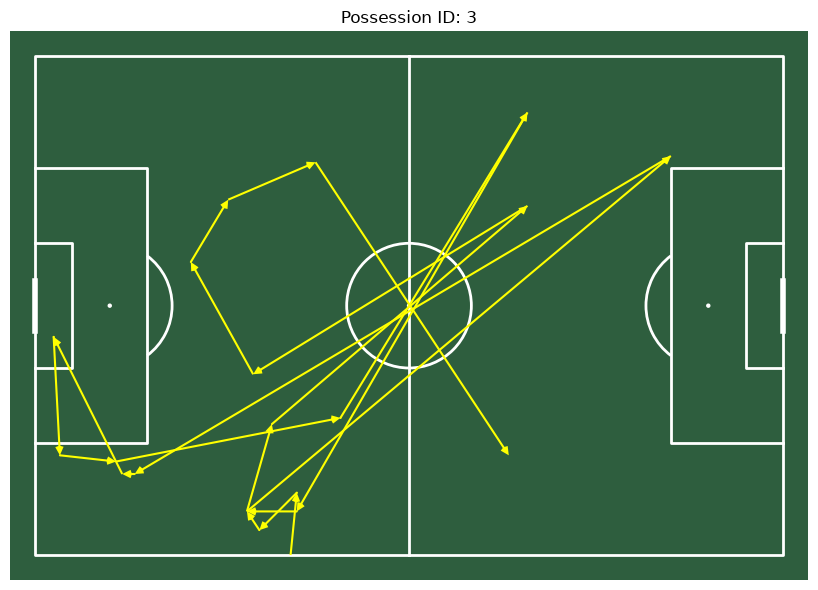

In [28]:
poss_ids, poss_chains = get_possession_chains(test_match_id, playing_events_df)
visualise_possession_chain(poss_ids[1], poss_chains)

In [29]:
# get players, and positions for match
def get_lineups_and_subs(match_id, df):
    match_lineups = df.filter((pl.col('type') == 35) & (pl.col('match_id') == match_id))
    match_subs = df.filter((pl.col('type') == 26) & (pl.col('match_id') == match_id))

    teams = match_lineups.get_column('team').unique().to_list()

    lineup_dict = {}
    for team in teams:
        lineup_dict[int(team)] = match_lineups.filter(pl.col('team') == team).get_column('tactics')[0]

    subs_dict = {}
    for team in teams:
        subs_dict[int(team)] = []
        for sub in match_subs.filter(pl.col('team') == team).select(['player', 'position']).iter_rows(named=True):
            subs_dict[int(team)].append((sub['player'], sub['position']))

    return lineup_dict, subs_dict


In [30]:
def get_player_average_position_in_match(player_id, match_id, df):
    player_df = df.filter((pl.col('player') == player_id) & (pl.col('match_id') == match_id))
    avg_x = player_df.get_column('location_x').mean()
    avg_y = player_df.get_column('location_y').mean()
    return np.nan if avg_x is None else avg_x, np.nan if avg_y is None else avg_y

def get_player_average_position_in_possession(player_id, match_id, df):
    # average position of player when passing or receiving a pass in the match
    print(f"Getting average position for player {player_id} in match {match_id}")
    match_df = df.filter(pl.col('match_id') == match_id)
    player_df = match_df.filter(
        ((pl.col('player') == player_id) | (pl.col('pass_recipient') == player_id))
        & (pl.col('type') == 30)
    )  # type 30 = pass
    avg_x = player_df.get_column('location_x').mean()
    avg_y = player_df.get_column('location_y').mean()
    return np.nan if avg_x is None else avg_x, np.nan if avg_y is None else avg_y

def get_pass_network(match_id, team_id, df):
    match_df = df.filter((pl.col('match_id') == match_id) & (pl.col('team') == team_id))
    pass_df = match_df.filter(pl.col('type') == 30)  # type 30 = passs
    pass_network = {}
    
    for player in match_df.get_column('player').unique().to_list():
        if player is None:
            continue
        pass_network_for_player = {}
        player_passes = pass_df.filter(pl.col('player') == player)

        for pass_played in player_passes.select('pass_recipient').iter_rows(named=True):
            recipient = pass_played['pass_recipient']
            if recipient is not None:
                try:
                    pass_network_for_player[int(recipient)] += 1
                except KeyError:
                    pass_network_for_player[int(recipient)] = 1
        pass_network[int(player)] = pass_network_for_player
    
    return pass_network

def get_attacking_intent_pass_network(match_id, team_id, df):
    # passes forward in the attacking direction, i.e. passes that increase the x-coordinate of the recipient compared to the passer
    match_df = df.filter((pl.col('match_id') == match_id) & (pl.col('team') == team_id))
    pass_df = match_df.filter(pl.col('type') == 30)  # type 30 = pass
    pass_network = {}

    for player in match_df.get_column('player').unique().to_list():
        if player is None:
            continue
        pass_network_for_player = {}
        player_passes = pass_df.filter(pl.col('player') == player)

        for pass_played in player_passes.select(['pass_recipient', 'location_x', 'end_location_x']).iter_rows(named=True):
            recipient = pass_played['pass_recipient']
            passer_x = pass_played['location_x']
            recipient_x = pass_played['end_location_x']
            if recipient is not None and passer_x is not None and recipient_x is not None:
                if recipient_x > passer_x:  # only count passes that increase x-coordinate
                    try:
                        pass_network_for_player[int(recipient)] += (recipient_x - passer_x) / 10 # weight by distance of pass in x-direction
                    except KeyError:
                        pass_network_for_player[int(recipient)] = (recipient_x - passer_x) / 10
        pass_network[int(player)] = pass_network_for_player

    return pass_network

def get_defensive_intent_pass_network(match_id, team_id, df):
    # passes backward in the attacking direction, i.e. passes that decrease the x-coordinate of the recipient compared to the passer
    match_df = df.filter((pl.col('match_id') == match_id) & (pl.col('team') == team_id))
    pass_df = match_df.filter(pl.col('type') == 30)  # type 30 = pass
    pass_network = {}

    for player in match_df.get_column('player').unique().to_list():
        if player is None:
            continue
        pass_network_for_player = {}
        player_passes = pass_df.filter(pl.col('player') == player)

        for pass_played in player_passes.select(['pass_recipient', 'location_x', 'end_location_x']).iter_rows(named=True):
            recipient = pass_played['pass_recipient']
            passer_x = pass_played['location_x']
            recipient_x = pass_played['end_location_x']
            if recipient is not None and passer_x is not None and recipient_x is not None:
                if recipient_x < passer_x:  # only count passes that decrease x-coordinate
                    try:
                        pass_network_for_player[int(recipient)] += (passer_x - recipient_x) / 10# weight by distance of pass in x-direction
                    except KeyError:
                        pass_network_for_player[int(recipient)] = (passer_x - recipient_x) / 10
        pass_network[int(player)] = pass_network_for_player

    return pass_network

def plot_pass_network(match_id, df, team_id, lineup, colour='white', 
                      radius=2, pass_network_func=get_pass_network, title_prefix=''):
    pass_network = pass_network_func(match_id, team_id, df)
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#2e5e3e', line_color='white')
    fig, ax = pitch.draw(figsize=(10, 6))

    lineup_ids = [player['player']['id'] for player in lineup]
    lineup_names = {player['player']['id']: player['player']['name'] for player in lineup}
    lineup_positions = {player['player']['id']: player['position']['id'] for player in lineup}

    avg_pos = {player_id: get_player_average_position_in_possession(player_id, match_id, df) for player_id in lineup_ids}
    
    for passer in lineup_ids:
        passer_avg_x, passer_avg_y = avg_pos[passer]
        passer_avg_x -= radius
        passer_avg_y -= radius

        circle = plt.Circle((passer_avg_x, passer_avg_y), radius=radius, color='#FF4444',
                         edgecolor='white', linewidth=3, zorder=5)
        ax.add_patch(circle)
        ax.text(passer_avg_x, passer_avg_y, positions_abbrev_dict[lineup_positions[passer]], color='white', 
                fontsize=8, ha='center', va='center', zorder=6)

        for recipient in lineup_ids:
            recipient_avg_x, recipient_avg_y = avg_pos[recipient]
            count = pass_network[passer].get(recipient)

            if count is not None:
                pitch.arrows(passer_avg_x, passer_avg_y, recipient_avg_x-radius, recipient_avg_y-radius,
                            width=count/5, headwidth=8, headlength=8,
                            color=colour, ax=ax)
    
    plt.title(f"{title_prefix} Pass Network for Match ID, Team ID: {match_id}, {team_id}")
    plt.show()


In [31]:
pn = get_pass_network(3879600, 1683, playing_events_df)

Getting average position for player 22032 in match 19804
Getting average position for player 19592 in match 19804
Getting average position for player 19502 in match 19804
Getting average position for player 19503 in match 19804
Getting average position for player 15569 in match 19804
Getting average position for player 19501 in match 19804
Getting average position for player 10193 in match 19804
Getting average position for player 15563 in match 19804
Getting average position for player 15562 in match 19804
Getting average position for player 15557 in match 19804
Getting average position for player 10180 in match 19804


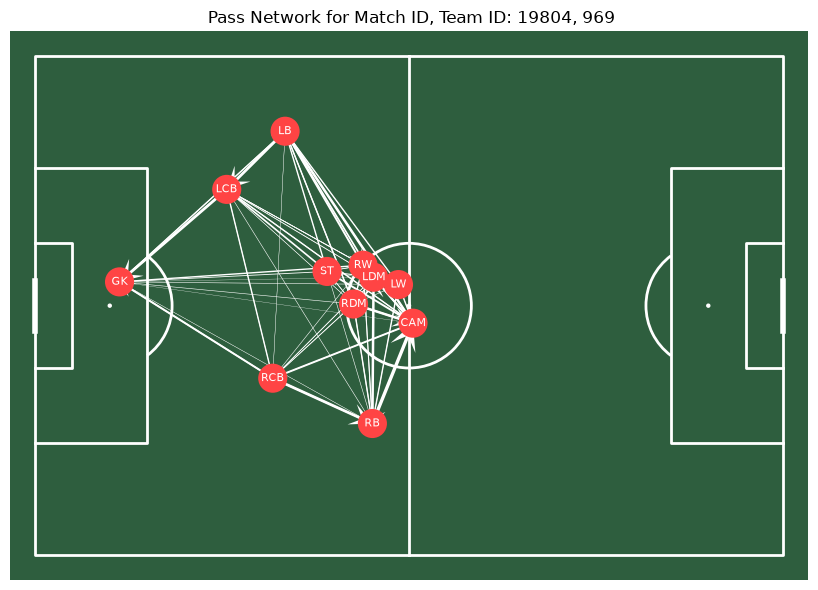

In [32]:
lineups, subs = get_lineups_and_subs(test_match_id, events_df)
plot_pass_network(test_match_id, playing_events_df, test_team_2_id, lineups[test_team_2_id]['lineup'])

Getting average position for player 22032 in match 19804
Getting average position for player 19592 in match 19804
Getting average position for player 19502 in match 19804
Getting average position for player 19503 in match 19804
Getting average position for player 15569 in match 19804
Getting average position for player 19501 in match 19804
Getting average position for player 10193 in match 19804
Getting average position for player 15563 in match 19804
Getting average position for player 15562 in match 19804
Getting average position for player 15557 in match 19804
Getting average position for player 10180 in match 19804


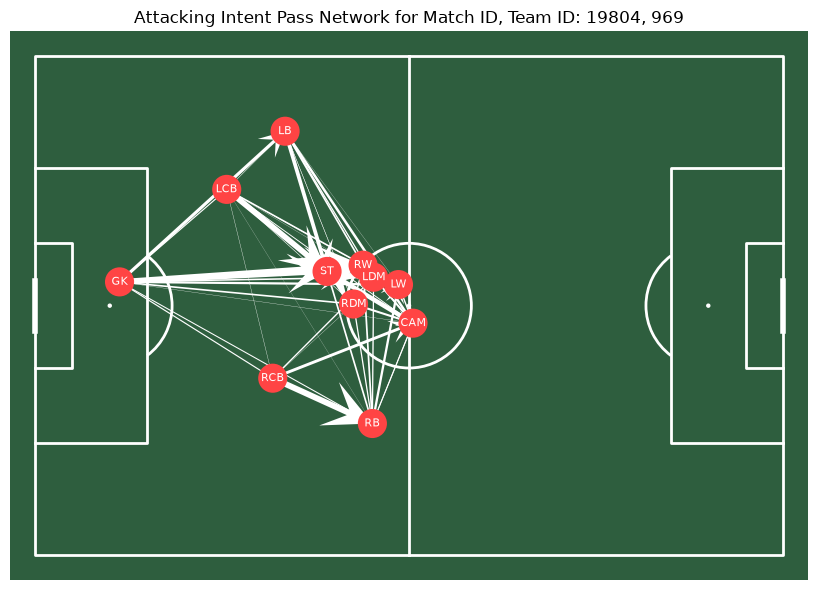

In [33]:
plot_pass_network(test_match_id, playing_events_df, test_team_2_id, lineups[test_team_2_id]['lineup'], pass_network_func=get_attacking_intent_pass_network, title_prefix='Attacking Intent')

Getting average position for player 22032 in match 19804
Getting average position for player 19592 in match 19804
Getting average position for player 19502 in match 19804
Getting average position for player 19503 in match 19804
Getting average position for player 15569 in match 19804
Getting average position for player 19501 in match 19804
Getting average position for player 10193 in match 19804
Getting average position for player 15563 in match 19804
Getting average position for player 15562 in match 19804
Getting average position for player 15557 in match 19804
Getting average position for player 10180 in match 19804


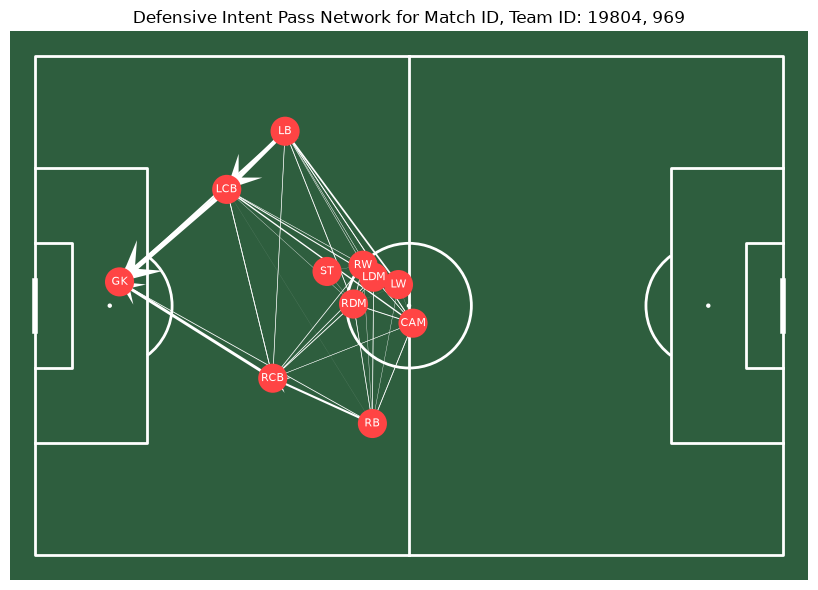

In [34]:
plot_pass_network(test_match_id, playing_events_df, test_team_2_id, lineups[test_team_2_id]['lineup'], pass_network_func=get_defensive_intent_pass_network, title_prefix='Defensive Intent')

In [35]:
# types of pass networks and positions to determine winners of matches
# types of in-possession / oop shapes to determine winners of matches